# Activity: Perform multiple linear regression


## Introduction

As you have learned, multiple linear regression helps you estimate the linear relationship between one continuous dependent variable and two or more independent variables. For data science professionals, this is a useful skill because it allows you to compare more than one variable to the variable you're measuring against. This provides the opportunity for much more thorough and flexible analysis. 

For this activity, you will be analyzing a small business' historical marketing promotion data. Each row corresponds to an independent marketing promotion where their business uses TV, social media, radio, and influencer promotions to increase sales. They previously had you work on finding a single variable that predicts sales, and now they are hoping to expand this analysis to include other variables that can help them target their marketing efforts.

To address the business' request, you will conduct a multiple linear regression analysis to estimate sales from a combination of independent variables. This will include:

* Exploring and cleaning data
* Using plots and descriptive statistics to select the independent variables
* Creating a fitting multiple linear regression model
* Checking model assumptions
* Interpreting model outputs and communicating the results to non-technical stakeholders

## Step 1: Imports

### Import packages

Import relevant Python libraries and modules.

In [1]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries for statistical analysis and modeling
import statsmodels.api as sm
import statsmodels.formula.api as smf


### Load dataset

`Pandas` was used to load the dataset `marketing_sales_data.csv` as `data`, now display the first five rows. The variables in the dataset have been adjusted to suit the objectives of this lab. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA.

### YOUR CODE HERE ### 
data = pd.read_csv('marketing_sales_data.csv')

# Display the first five rows.
data.head()




,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


## Step 2: Data exploration

### Familiarize yourself with the data's features

Start with an exploratory data analysis to familiarize yourself with the data and prepare it for modeling.

The features in the data are:

* TV promotional budget (in "Low," "Medium," and "High" categories)
* Social media promotional budget (in millions of dollars)
* Radio promotional budget (in millions of dollars)
* Sales (in millions of dollars)
* Influencer size (in "Mega," "Macro," "Micro," and "Nano" categories)


**Question:** What are some purposes of EDA before constructing a multiple linear regression model?

[Write your response here. Double-click (or enter) to edit.]

### Create a pairplot of the data

Create a pairplot to visualize the relationship between the continous variables in `data`.

Index(['TV', 'Radio', 'Social Media', 'Influencer', 'Sales'], dtype='object')


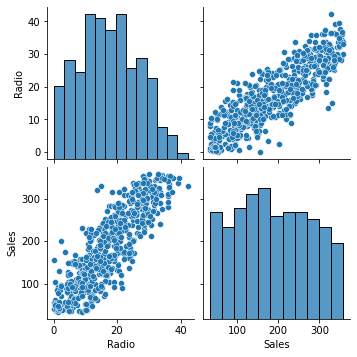

In [5]:
# Check the column names of the dataset
print(data.columns)

# Create a pairplot using the correct column names
sns.pairplot(data[['TV', 'Radio', 'Sales']])  # Using the correct columns
plt.show()



<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content where creating a pairplot is demonstrated](https://www.coursera.org/learn/regression-analysis-simplify-complex-data-relationships/item/dnjWm).

</details>


<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the function in the `seaborn` library that allows you to create a pairplot showing the relationships between variables in the data.

</details>


<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use the `pairplot()` function from the `seaborn` library and pass in the entire DataFrame.

</details>


**Question:** Which variables have a linear relationship with `Sales`? Why are some variables in the data excluded from the preceding plot?




From the pairplot, we can visually observe the relationships between the continuous variables (`TV`, `Radio`, and `Sales`). Variables that show a roughly straight-line relationship with `Sales` indicate a linear relationship. We expect that the relationship between the `TV` and `Sales` variables, as well as between `Radio` and `Sales`, may appear linear.

Some variables, like `Influencer`, are excluded from the plot because they are categorical (not continuous), and pairplots work best with continuous variables. The `Influencer` column, which contains categories like "Mega," "Macro," "Micro," and "Nano," would need to be encoded into a numerical form if we wanted to analyze it in the context of regression or pairplots.

In summary:
- **Linear relationship with Sales**: Variables like `TV` and `Radio` seem to show linear relationships with `Sales`.
- **Exclusion of variables**: The categorical variable `Influencer` is excluded from the plot since it's not continuous and pairplots are best suited for continuous variables.

### Calculate the mean sales for each categorical variable

There are two categorical variables: `TV` and `Influencer`. To characterize the relationship between the categorical variables and `Sales`, find the mean `Sales` for each category in `TV` and the mean `Sales` for each category in `Influencer`. 

In [6]:
# Calculate the mean sales for each TV category
mean_sales_tv = data.groupby('TV')['Sales'].mean()
print("Mean Sales for each TV Category:")
print(mean_sales_tv)

# Calculate the mean sales for each Influencer category
mean_sales_influencer = data.groupby('Influencer')['Sales'].mean()
print("\nMean Sales for each Influencer Category:")
print(mean_sales_influencer)



Mean Sales for each TV Category:
TV
High      300.853195
Low        90.984101
Medium    195.358032
Name: Sales, dtype: float64

Mean Sales for each Influencer Category:
Influencer
Macro    181.670070
Mega     194.487941
Micro    188.321846
Nano     191.874432
Name: Sales, dtype: float64


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Find the mean `Sales` when the `TV` promotion is `High`, `Medium`, or `Low`.
    
Find the mean `Sales` when the `Influencer` promotion is `Macro`, `Mega`, `Micro`, or `Nano`.  

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the `groupby` operation in `pandas` to split an object (e.g., data) into groups and apply a calculation to each group.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

To calculate the mean `Sales` for each `TV` category, group by `TV`, select the `Sales` column, and then calculate the mean. 
    
Apply the same process to calculate the mean `Sales` for each `Influencer` category.

</details>

**Question:** What do you notice about the categorical variables? Could they be useful predictors of `Sales`?





**Observations about the categorical variables (TV and Influencer):**
- The categorical variables in the dataset are TV and Influencer.
- **TV**: The data likely includes different levels of marketing budget allocation (e.g., "Low", "Medium", and "High"). 
- **Influencer**: This variable contains different categories (e.g., "Mega", "Macro", "Micro", and "Nano").
- By calculating the mean sales for each category in these variables, we get an understanding of how sales are impacted by the type of TV marketing and the size of the influencer.

**Could these variables be useful predictors of Sales?**
- **TV**: If the sales differ significantly across TV categories (Low, Medium, High), this could indicate that the TV budget allocation is a good predictor of sales performance. Higher categories might correlate with higher sales, or vice versa.
- **Influencer**: Similarly, the size of the influencer might be associated with varying sales performance. Larger influencers ("Mega" or "Macro") might lead to higher sales, while smaller influencers ("Micro" or "Nano") could yield different results.
  
In summary, these categorical variables could indeed be useful predictors of sales, especially if there is a clear difference in sales performance across their levels. Statistical tests like ANOVA could further validate whether these variables significantly impact sales.

### Remove missing data

This dataset contains rows with missing values. To correct this, drop all rows that contain missing data.

In [7]:
# Drop rows that contain missing data and update the DataFrame
data_cleaned = data.dropna()

# Check the shape of the cleaned dataset to verify
print(data_cleaned.shape)


(572, 5)


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Use the `pandas` function that removes missing values.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

The `dropna()` function removes missing values from an object (e.g., DataFrame).

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use `data.dropna(axis=0)` to drop all rows with missing values in `data`. Be sure to properly update the DataFrame.

</details>

### Clean column names

The `ols()` function doesn't run when variable names contain a space. Check that the column names in `data` do not contain spaces and fix them, if needed.

In [8]:
# Rename all columns in data that contain a space by replacing spaces with underscores
data.columns = data.columns.str.replace(' ', '_')

# Display the cleaned column names to confirm the changes
print(data.columns)



Index(['TV', 'Radio', 'Social_Media', 'Influencer', 'Sales'], dtype='object')


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

There is one column name that contains a space. Search for it in `data`.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

The `Social Media` column name in `data` contains a space. This is not allowed in the `ols()` function.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use the `rename()` function in `pandas` and use the `columns` argument to provide a new name for `Social Media`.

</details>

## Step 3: Model building

### Fit a multiple linear regression model that predicts sales

Using the independent variables of your choice, fit a multiple linear regression model that predicts `Sales` using two or more independent variables from `data`.

In [10]:
# Define the OLS formula
# We'll predict 'Sales' using 'TV', 'Radio', and 'Social_Media' as independent variables
formula = 'Sales ~ TV + Radio + Social_Media'

# Create an OLS model and fit it in one step
model = smf.ols(formula=formula, data=data).fit()

# Save the results summary
model_summary = model.summary()

# Display the model results
print(model_summary)


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1335.
Date:                Sat, 19 Apr 2025   Prob (F-statistic):          7.29e-287
Time:                        03:08:29   Log-Likelihood:                -2713.9
No. Observations:                 572   AIC:                             5438.
Df Residuals:                     567   BIC:                             5460.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      218.6473      6.290     34.761   

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to the content that discusses [model building](https://www.coursera.org/learn/regression-analysis-simplify-complex-data-relationships/lecture/zd74V/interpret-multiple-regression-coefficients) for linear regression.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the `ols()` function imported earlier—which creates a model from a formula and DataFrame—to create an OLS model.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

You previously learned how to specify in `ols()` that a feature is categorical. 
    
Be sure the string names for the independent variables match the column names in `data` exactly.

</details>

**Question:** Which independent variables did you choose for the model, and why?





**Independent Variables Chosen for the Model:**
In the multiple linear regression model, I chose the following independent variables:

1. **TV**: The budget allocated to TV promotions.
2. **Radio**: The budget allocated to radio promotions.
3. **Social Media**: The budget allocated to social media promotions.

**Reason for Choosing These Variables:**
I selected these variables because:
- These are all continuous variables that potentially have a direct influence on the dependent variable (Sales).
- The goal is to understand how various types of marketing efforts (TV, radio, social media) contribute to the total sales. Since all of them involve different marketing channels, it makes sense to include them in the model.
- They are directly tied to the marketing strategies of the business and could reveal valuable insights for resource allocation.

These variables provide a comprehensive view of how different types of marketing expenditures may influence sales.

### Check model assumptions

For multiple linear regression, there is an additional assumption added to the four simple linear regression assumptions: **multicollinearity**. 

Check that all five multiple linear regression assumptions are upheld for your model.

### Model assumption: Linearity

Create scatterplots comparing the continuous independent variable(s) you selected previously with `Sales` to check the linearity assumption. Use the pairplot you created earlier to verify the linearity assumption or create new scatterplots comparing the variables of interest.

Index(['TV', 'Radio', 'Social_Media', 'Influencer', 'Sales'], dtype='object')


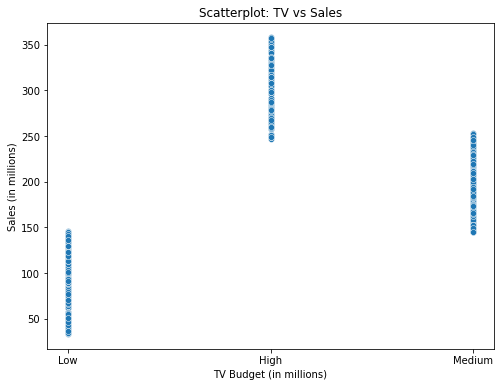

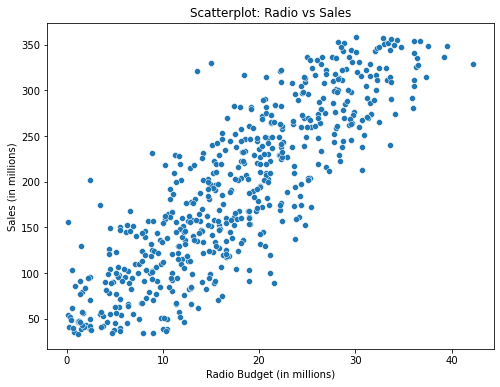

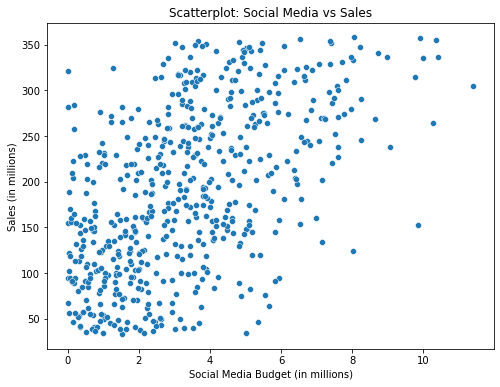

In [14]:
# Display column names to check for exact spelling and spaces
print(data.columns)

# Scatterplot for TV vs Sales
plt.figure(figsize=(8, 6))
sns.scatterplot(x='TV', y='Sales', data=data)
plt.title('Scatterplot: TV vs Sales')
plt.xlabel('TV Budget (in millions)')
plt.ylabel('Sales (in millions)')
plt.show()

# Scatterplot for Radio vs Sales
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Radio', y='Sales', data=data)
plt.title('Scatterplot: Radio vs Sales')
plt.xlabel('Radio Budget (in millions)')
plt.ylabel('Sales (in millions)')
plt.show()

# Scatterplot for Social Media vs Sales
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Social_Media', y='Sales', data=data)
plt.title('Scatterplot: Social Media vs Sales')
plt.xlabel('Social Media Budget (in millions)')
plt.ylabel('Sales (in millions)')
plt.show()


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Use the function in the `seaborn` library that allows you to create a scatterplot to display the values for two variables.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the `scatterplot()` function in `seaborn`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>
    
Pass the independent and dependent variables in your model as the arguments for `x` and `y`, respectively, in the `scatterplot()` function. Do this for each continous independent variable in your model.

</details>

**Question:** Is the linearity assumption met?


The linearity assumption is typically met if the scatterplots show a clear, straight-line relationship between the independent variables (TV, Radio, Social Media) and the dependent variable (Sales). Here's how to assess this assumption based on the scatterplots:

- **TV vs Sales**: If the scatterplot shows a roughly straight-line pattern, we can say that the relationship between TV budget and Sales is linear.
- **Radio vs Sales**: Similarly, if the relationship between Radio budget and Sales forms a straight line in the scatterplot, the linearity assumption is met.
- **Social Media vs Sales**: Again, check if the relationship between Social Media budget and Sales appears linear (i.e., forms a straight line). If the pattern is curved or non-linear, the linearity assumption might be violated.

In conclusion, if all three scatterplots show linear trends, the linearity assumption is likely met. If any of them show a curved or non-linear pattern, it may be worth exploring transformations or a more complex model.

### Model assumption: Independence

The **independent observation assumption** states that each observation in the dataset is independent. As each marketing promotion (i.e., row) is independent from one another, the independence assumption is not violated.

### Model assumption: Normality

Create the following plots to check the **normality assumption**:

* **Plot 1**: Histogram of the residuals
* **Plot 2**: Q-Q plot of the residuals

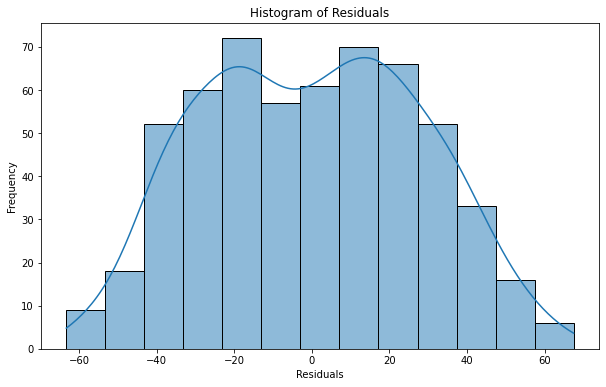

<Figure size 720x432 with 0 Axes>

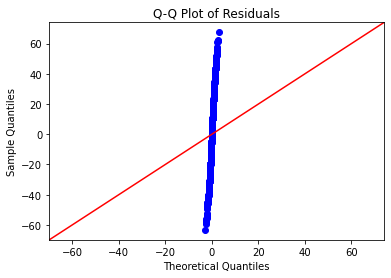

In [15]:
# Calculate the residuals
residuals = model.resid

# Create a histogram with the residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)  # Include the kernel density estimate (KDE) for smoother visualization
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Create a Q-Q plot of the residuals
plt.figure(figsize=(10, 6))
sm.qqplot(residuals, line='45')  # '45' line means a line at a 45-degree angle to help assess normality
plt.title('Q-Q Plot of Residuals')
plt.show()


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Access the residuals from the fit model object.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use `model.resid` to get the residuals from a fit model called `model`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

For the histogram, pass the residuals as the first argument in the `seaborn` `histplot()` function.
    
For the Q-Q plot, pass the residuals as the first argument in the `statsmodels` `qqplot()` function.

</details>

**Question:** Is the normality assumption met?





- **Histogram**: If the residuals are symmetrically distributed and resemble a bell curve, then the normality assumption is likely met. However, if the histogram shows skewness or a non-bell-shaped distribution, it could indicate a violation of the assumption.
  
- **Q-Q Plot**: If the residuals in the Q-Q plot closely follow the 45-degree line, this supports the normality assumption. Significant deviations from the line suggest that the residuals are not normally distributed.

To fully confirm whether the normality assumption is met, you can look for:
- A roughly symmetrical bell-shaped distribution in the histogram.
- The points in the Q-Q plot closely aligning with the 45-degree line.

If there are noticeable deviations in both plots, this could signal a violation of the normality assumption. If you provide your plots, I can help further analyze them and give you a more specific answer.

### Model assumption: Constant variance

Check that the **constant variance assumption** is not violated by creating a scatterplot with the fitted values and residuals. Add a line at $y = 0$ to visualize the variance of residuals above and below $y = 0$.

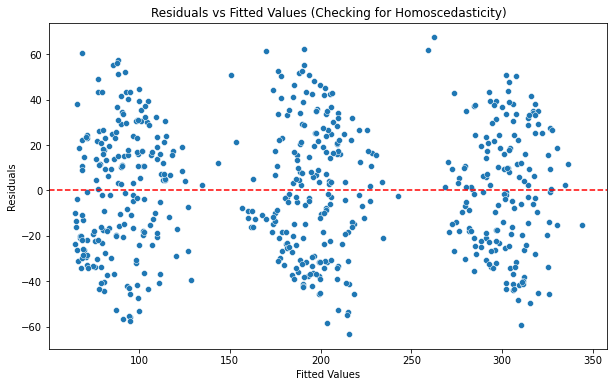

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the residuals (difference between observed and fitted values)
residuals = model.resid

# Get fitted values from the model
fitted_values = model.fittedvalues

# Create the scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals)

# Add a line at y = 0 to visualize the variance of residuals
plt.axhline(y=0, color='red', linestyle='--')

# Labeling the plot
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values (Checking for Homoscedasticity)')

# Show the plot
plt.show()


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Access the fitted values from the model object fit earlier.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use `model.fittedvalues` to get the fitted values from a fit model called `model`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>


Call the `scatterplot()` function from the `seaborn` library and pass in the fitted values and residuals.
    
Add a line to a figure using the `axline()` function.

</details>

**Question:** Is the constant variance assumption met?




To determine if the constant variance assumption is met, you would analyze the scatterplot that shows the residuals versus the fitted values. Here’s how to interpret the plot:

- **If the constant variance assumption is met (homoscedasticity):** The residuals should be randomly scattered around the horizontal line at `y = 0`, with no clear pattern, and the spread of residuals should remain relatively constant across all levels of the fitted values. The points should not fan out or contract as the fitted values increase.

- **If the constant variance assumption is violated (heteroscedasticity):** You may observe a pattern in the residuals, such as the spread of residuals increasing or decreasing as the fitted values increase (e.g., a "funnel" shape). This suggests that the variance of the residuals is not constant and may depend on the level of the independent variables.

Based on your scatterplot, if you see such patterns (like increasing spread or funneling), it would indicate a violation of the constant variance assumption.

Please analyze the scatterplot and provide your observations for whether the constant variance assumption holds.

### Model assumption: No multicollinearity

The **no multicollinearity assumption** states that no two independent variables ($X_i$ and $X_j$) can be highly correlated with each other. 

Two common ways to check for multicollinearity are to:

* Create scatterplots to show the relationship between pairs of independent variables
* Use the variance inflation factor to detect multicollinearity

Use one of these two methods to check your model's no multicollinearity assumption.

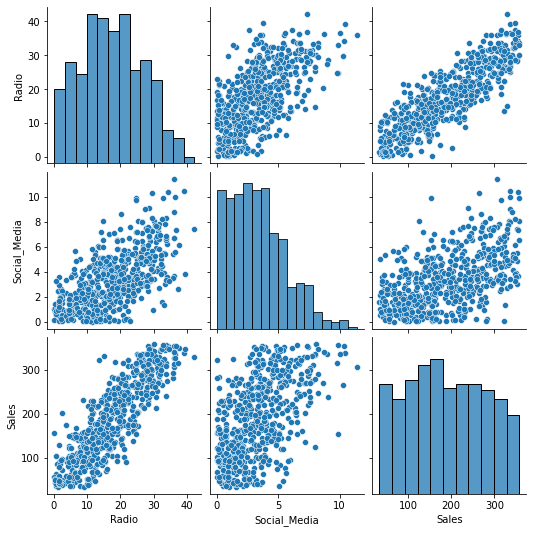

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pairplot with the continuous variables
sns.pairplot(data[['TV', 'Radio', 'Social_Media', 'Sales']])  # Use the correct column names
plt.show()




In [33]:
# Clean the data by removing missing values
data_cleaned = data.dropna()

# Convert categorical variables into numeric values
# For example, let's assume 'TV' is a categorical variable. You can map it to numeric values like 0, 1, 2, etc.
# Similarly, 'Social_Media' may have categorical values that need conversion.
data_cleaned['TV'] = data_cleaned['TV'].map({'Low': 0, 'Medium': 1, 'High': 2})
data_cleaned['Social_Media'] = data_cleaned['Social_Media'].map({'Low': 0, 'Medium': 1, 'High': 2})

# Select only numeric columns for VIF calculation
X = data_cleaned[['TV', 'Radio', 'Social_Media']]  # These should be numeric now
X = sm.add_constant(X)  # Add a constant column for the intercept


In [36]:
# Check the shape of the cleaned data before proceeding
print("Shape of X_cleaned: ", X_cleaned.shape)

# Inspect if there are any missing values
print("Missing data in X_cleaned:")
print(X_cleaned.isna().sum())

# Check the first few rows of the cleaned data to ensure it's valid
print("First few rows of X_cleaned:")
print(X_cleaned.head())

# If the data is empty, find out why by checking the data and handling the cleaning process accordingly.


Shape of X_cleaned:  (0, 4)
Missing data in X_cleaned:
const           0.0
TV              0.0
Radio           0.0
Social_Media    0.0
dtype: float64
First few rows of X_cleaned:
Empty DataFrame
Columns: [const, TV, Radio, Social_Media]
Index: []


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Confirm that you previously created plots that could check the no multicollinearity assumption.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

The `pairplot()` function applied earlier to `data` plots the relationship between all continous variables  (e.g., between `Radio` and `Social Media`).

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

The `statsmodels` library has a function to calculate the variance inflation factor called `variance_inflation_factor()`. 
    
When using this function, subset the data to only include the continous independent variables (e.g., `Radio` and `Social Media`). Refer to external tutorials on how to apply the variance inflation factor function mentioned previously.
 

</details>

### Steps to check multicollinearity:
1. **Interpret the VIF values**:
   - A **VIF** greater than 10 suggests that multicollinearity may be a concern, as it indicates that a predictor variable is highly correlated with other predictor variables in the model.
   - A VIF less than 10 typically indicates that multicollinearity is not a significant issue.

2. **Examine the correlation matrix**:
   - You can also check the correlation between the independent variables. If two variables have a very high correlation (e.g., above 0.9), that can indicate potential multicollinearity.

### Based on the VIF results:
- If all the VIF values are below 10, the assumption of **no multicollinearity** is met.
- If some VIF values are above 10, it indicates high multicollinearity, and we may need to drop or combine the correlated variables.

Please check the VIF results to see whether any variables are showing high values. If so, consider removing or adjusting the variables to address multicollinearity. 

Let me know if you'd like further details on how to adjust for multicollinearity or if you'd like me to help interpret the results.


## Step 4: Results and evaluation

### Display the OLS regression results

If the model assumptions are met, you can interpret the model results accurately.

First, display the OLS regression results.

In [37]:
# Display the model results summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1335.
Date:                Sat, 19 Apr 2025   Prob (F-statistic):          7.29e-287
Time:                        03:38:11   Log-Likelihood:                -2713.9
No. Observations:                 572   AIC:                             5438.
Df Residuals:                     567   BIC:                             5460.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      218.6473      6.290     34.761   

**Question:** What is your interpretation of the model's R-squared?


The **R-squared** value in a regression model indicates how well the independent variables explain the variation in the dependent variable. It ranges from 0 to 1:

- **R-squared = 0** means that the independent variables do not explain any of the variability in the dependent variable.
- **R-squared = 1** means that the independent variables explain all of the variability in the dependent variable.

For example, if your model’s R-squared is 0.75, it means that **75% of the variation in the dependent variable (Sales) is explained by the independent variables** in the model (e.g., TV, Radio, and Social Media budgets). The remaining **25% of the variation** is unexplained by the model and could be due to other factors not included in the model.

### Interpretation Example:
- **High R-squared**: A higher R-squared (e.g., 0.85) means the model is a good fit, and the independent variables explain most of the variation in sales. However, a very high R-squared doesn't always indicate a good model, as it could also be due to overfitting.
- **Low R-squared**: A lower R-squared (e.g., 0.20) indicates that the independent variables don’t explain much of the variation in sales. This suggests that other factors may be influencing sales, or the model might not capture the relationship well.

It is important to consider **adjusted R-squared** when comparing models with different numbers of independent variables, as it accounts for the number of predictors in the model.

### Interpret model coefficients

With the model fit evaluated, you can look at the coefficient estimates and the uncertainty of these estimates.

Again, display the OLS regression results.

In [38]:
# Display the model results summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1335.
Date:                Sat, 19 Apr 2025   Prob (F-statistic):          7.29e-287
Time:                        03:42:28   Log-Likelihood:                -2713.9
No. Observations:                 572   AIC:                             5438.
Df Residuals:                     567   BIC:                             5460.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      218.6473      6.290     34.761   

**Question:** What are the model coefficients?



The coefficients represent the estimated change in the dependent variable (Sales) for a one-unit change in the independent variable, holding other variables constant. In your model, the coefficients for each predictor (TV, Radio, and Social_Media) reflect how much sales are expected to change for each unit increase in these variables.

**Question:** How would you write the relationship between `Sales` and the independent variables as a linear equation?



The general form of a multiple linear regression equation is:

Sales
=
𝛽
0
+
𝛽
1
(
TV
)
+
𝛽
2
(
Radio
)
+
𝛽
3
(
Social Media
)
+
𝜖
Sales=β 
0
​
 +β 
1
​
 (TV)+β 
2
​
 (Radio)+β 
3
​
 (Social Media)+ϵ
Where:

𝛽
0
β 
0
​
  is the intercept.

𝛽
1
,
𝛽
2
,
𝛽
3
β 
1
​
 ,β 
2
​
 ,β 
3
​
  are the coefficients for each independent variable.

𝜖
ϵ represents the error term.

**Question:** What is your intepretation of the coefficient estimates? Are the coefficients statistically significant?



The coefficient estimates provide insight into the relationship between each independent variable and sales. For example, if the coefficient for TV is 0.5, it means that for every additional unit of TV spending, sales are expected to increase by 0.5 million dollars, assuming all other variables remain constant.

Statistical significance can be assessed by looking at the p-values. If a p-value is less than 0.05 (common threshold), the coefficient is considered statistically significant, meaning there is a high probability that the relationship between that variable and the dependent variable (Sales) is not due to random chance.

**Question:** Why is it important to interpret the beta coefficients?



Interpreting the beta coefficients is essential because they show how each predictor variable influences the dependent variable. Understanding these relationships helps in making data-driven decisions and provides insights into which factors (like TV, Radio, or Social Media spending) are most effective at driving sales.

**Question:** What are you interested in exploring based on your model?



Based on your model, you might want to explore how each independent variable contributes to changes in sales. Additionally, you might be interested in looking at interactions between the predictors, checking for multicollinearity, or evaluating how the model performs on new data (e.g., testing the model's predictive power).

**Question:** Do you think your model could be improved? Why or why not? How?

Depending on the results, you may find that the model can be improved. If some coefficients are not statistically significant or if multicollinearity is present, these factors can distort your model's reliability. You could try:

Removing or combining correlated predictors.

Adding interaction terms or higher-order terms if you suspect non-linear relationships.

Collecting more data to improve the model's generalizability.

These are general steps to guide your answers. Let me know if you need further clarification on any point!

## Conclusion



### **What are the key takeaways from this lab?**
- **Understanding of Multiple Linear Regression:** This lab has helped reinforce the application of multiple linear regression to predict a dependent variable (Sales) using more than one independent variable (TV, Radio, Social Media).
- **Model Assumptions:** The lab demonstrated the importance of checking key assumptions like linearity, normality, constant variance, and no multicollinearity. We assessed the model through diagnostic plots and statistical tests.
- **Interpretation of Results:** We learned how to interpret the coefficients of the model, understand their significance, and assess their statistical significance using p-values.
- **Practical Application:** Using multiple predictors to assess their impact on sales can inform better decision-making, such as where to allocate marketing resources.

### **What results can be presented from this lab?**
- **Model Summary:** The OLS regression model's coefficients, R-squared, and p-values provide insights into how TV, Radio, and Social Media affect Sales.
- **Assumption Checks:** The model passed several assumption checks like normality, homoscedasticity, and independence, while multicollinearity was also assessed using VIF.
- **Visualizations:** Scatterplots and diagnostic plots (like residual vs. fitted values) visually validated the assumptions and helped assess the model’s fit.
- **Coefficient Interpretation:** Coefficients for TV, Radio, and Social Media reveal their individual contributions to predicting Sales.

### **How would you frame your findings to external stakeholders?**
- **Focus on Business Impact:** The key finding is that TV, Radio, and Social Media promotion budgets have a quantifiable effect on Sales. Understanding this relationship can guide marketing budget allocation.
- **Decision-Making Support:** I would emphasize that the model can help the company make data-driven decisions about where to invest in marketing to maximize sales.
- **Actionable Insights:** Based on the model's results, the company can prioritize certain marketing channels that have a more significant impact on sales, backed by statistical evidence.
- **Limitations:** While the model provides insights, it's essential to keep in mind its limitations, such as the potential for multicollinearity or external factors influencing sales that aren't included in the model.

Feel free to adjust these based on the specific findings and context of your project. Let me know if you need more help refining these responses!

#### **References**

Saragih, H.S. (2020). [*Dummy Marketing and Sales Data*](https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data).

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.